<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/Econ_3916_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Manual DGP Simulation
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [3]:
def calculate_mad(data):
    # 1. Calculate the Median of the data
    median = np.median(data)
    # 2. Calculate Absolute Deviations (|x - median|)
    deviations = np.abs(data - median)
    # 3. Return the Median of those deviations
    return np.median(deviations)

sd_latency = np.std(latency_logs, ddof=1)
mad_latency = calculate_mad(latency_logs)

print(f"Standard Deviation of Latency: {sd_latency}")
print(f"Median Absolute Deviation of Latency: {mad_latency}")

Standard Deviation of Latency: 475.58525175902025
Median Absolute Deviation of Latency: 7.0


SD is much higher exploded because squaring the deviations amplifies outliers, making them dominate the calculation. MAD stays stable because it takes the median value of deviations, and a small percentage of outliers can't shift the median.

In [8]:
def bayesian_audit(prior, sensitivity, specificity):
    tp_rate = sensitivity

    fp_rate = 1 - specificity

    p_flagged = (tp_rate * prior) + (fp_rate * (1 - prior))

    posterior = (tp_rate * prior) / p_flagged

    return posterior

sensitivity = 0.98
specificity = 0.98

print("Bootcamp, Base Rate = 50%):")
print(f"P(Cheater | Flagged) = {bayesian_audit(0.50, sensitivity, specificity)}")
print()

print("Scenario B (Econ Class, Base Rate = 5%):")
print(f"P(Cheater | Flagged) = {bayesian_audit(0.05, sensitivity, specificity)}")
print()

print("Scenario C (Honors Seminar, Base Rate = 0.1%):")
print(f"P(Cheater | Flagged) = {bayesian_audit(0.001, sensitivity, specificity)}")

Bootcamp, Base Rate = 50%):
P(Cheater | Flagged) = 0.98

Scenario B (Econ Class, Base Rate = 5%):
P(Cheater | Flagged) = 0.7205882352941175

Scenario C (Honors Seminar, Base Rate = 0.1%):
P(Cheater | Flagged) = 0.04675572519083965


In [13]:
observed_control = 50250
observed_treatment = 49750

expected_control = 50000
expected_treatment = 50000

observed = np.array([observed_control, observed_treatment])
expected = np.array([expected_control, expected_treatment])

chi_square = 0
for i in range(len(observed)):
    chi_square += (observed[i] - expected[i])**2 / expected[i]

print(f"Chi-Square Statistic: {chi_square}")

if chi_square > 3.84:
    print("EXPERIMENT INVALID")
else:
    print("EXPERIMENT VALID")

Chi-Square Statistic: 2.5
EXPERIMENT VALID


Mean (All): $3,765.03
Mean (Survivors): $148,081.06
Bias: 39.33x


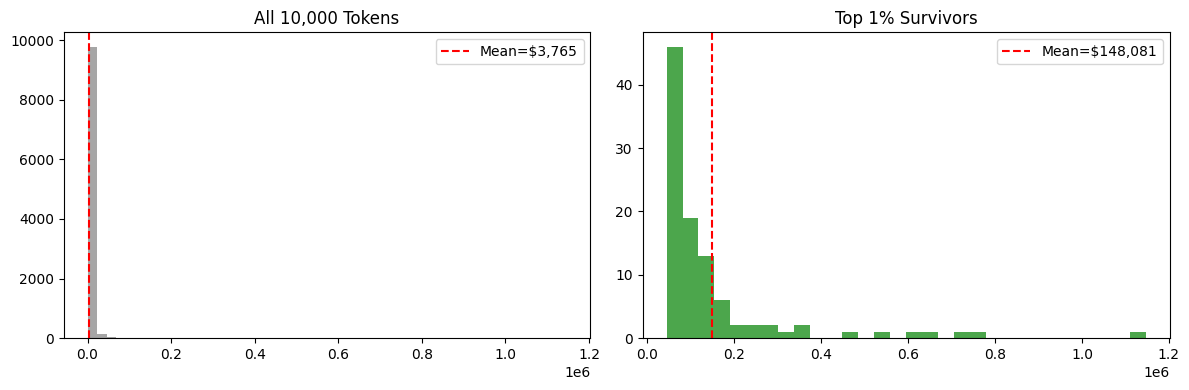

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate 10,000 token launches with Pareto distribution
market_caps = np.random.pareto(a=1.16, size=10000) * 1000

# All tokens vs Top 1% survivors
df_all = pd.DataFrame({'market_cap': market_caps})
df_survivors = df_all[df_all['market_cap'] >= np.percentile(market_caps, 99)]

# Calculate means
mean_all = df_all['market_cap'].mean()
mean_survivors = df_survivors['market_cap'].mean()

print(f"Mean (All): ${mean_all:,.2f}")
print(f"Mean (Survivors): ${mean_survivors:,.2f}")
print(f"Bias: {mean_survivors/mean_all:.2f}x")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df_all['market_cap'], bins=50, color='gray', alpha=0.7)
ax1.axvline(mean_all, color='red', linestyle='--', label=f'Mean=${mean_all:,.0f}')
ax1.set_title('All 10,000 Tokens')
ax1.legend()

ax2.hist(df_survivors['market_cap'], bins=30, color='green', alpha=0.7)
ax2.axvline(mean_survivors, color='red', linestyle='--', label=f'Mean=${mean_survivors:,.0f}')
ax2.set_title('Top 1% Survivors')
ax2.legend()

plt.tight_layout()
plt.show()